In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns
colors = sns.color_palette()

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    # The printed text block is 4.5 inches wide.
    "full_landscape": (4.50, 2.65),
    "full_standard": (4.50, 3.15),
    "full_tall": (4.50, 4.20),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "Greys",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="bold",
        va="top",
        ha="left",
        transform=None,
        bbox=dict(facecolor="white", edgecolor="none", pad=0.8, alpha=0.9),
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Particle filtering for a stochastic Duffing oscillator



A particle filter updates a distribution over an unobserved state as measurements arrive. This example applies the bootstrap filter from the DAX package {cite:p}`predictivesciencelab_dax` to a stochastic Duffing oscillator. The position is observed with noise, while a velocity-like state must be reconstructed from the dynamics and the position measurements.

In [3]:
import importlib.util
import json
import subprocess
import sys
from importlib import metadata

DAX_COMMIT = "65b4c1c21ad3b8add4ca0d104bb388ab38632590"
required_packages = {"diffrax": "diffrax", "optax": "optax", "blackjax": "blackjax", "seaborn": "seaborn"}
missing_packages = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])

try:
    direct_url = metadata.distribution("dax").read_text("direct_url.json")
    installed_dax_commit = json.loads(direct_url or "{}").get("vcs_info", {}).get("commit_id")
except metadata.PackageNotFoundError:
    installed_dax_commit = None

if installed_dax_commit != DAX_COMMIT:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--no-deps", "--force-reinstall",
        f"git+https://github.com/PredictiveScienceLab/dax.git@{DAX_COMMIT}",
    ])

In [4]:
import dax
import equinox as eqx
import jax
import jax.random as jr
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
key = jr.PRNGKey(0)

## State-space model

The deterministic forced Duffing oscillator is described by

$$
\ddot{x} + \delta \dot{x} + \alpha x + \beta x^3
= \gamma \cos(\omega t).
$$

The parameters $\delta$, $\alpha$, and $\beta$ determine the damping and restoring force. The periodic input has frequency $\omega$ and amplitude $\gamma$. The negative linear stiffness $\alpha=-1$ and positive cubic stiffness $\beta=1$ produce a bistable restoring force. The filtering task treats every model parameter as known and reconstructs the time-dependent state.

To represent unresolved dynamics, define the state $\boldsymbol{X}_t=(X_{1,t},X_{2,t})^{\mathsf T}$, where $X_1$ is position and $X_2$ is a velocity-like state. The control $u(t)=\cos(\omega t)$ is dimensionless, and $\gamma$ remains the forcing amplitude. The Itô model is

$$
\begin{aligned}
dX_{1,t} &= X_{2,t}\,dt + \sigma_x\,dW_{1,t}, \\
dX_{2,t} &= \left[\gamma u(t)-\delta X_{2,t}-\alpha X_{1,t}-\beta X_{1,t}^3\right]dt + \sigma_v\,dW_{2,t}.
\end{aligned}
$$

The Brownian motions $W_1$ and $W_2$ are independent. In the deterministic limit $\sigma_x=0$, $X_2=\dot X_1$; with direct Brownian forcing on position, $X_1$ is not differentiable and this equality is no longer literal.

In [5]:
# Define the right-hand side, deterministic part of the Duffing oscillator
class DuffingControl(dax.ControlFunction):

    omega: jax.Array

    def __init__(self, omega):
        self.omega = jnp.array(omega)
    
    def _eval(self, t):
        # Hold the forcing frequency fixed.
        omega = jax.lax.stop_gradient(self.omega)
        return jnp.cos(omega * t)

# Define the stochastic differential equation
class Duffing(dax.StochasticDifferentialEquation):

    alpha: jax.Array
    beta: jax.Array
    delta: jax.Array

    gamma: jax.Array
    log_sigma_x: jax.Array
    log_sigma_v: jax.Array

    @property
    def sigma_x(self):
        return jnp.exp(self.log_sigma_x)

    @property
    def sigma_v(self):
        return jnp.exp(self.log_sigma_v)

    def __init__(self, alpha, beta, gamma, delta, sigma_x, sigma_v, u):
        super().__init__(control_function=u)
        self.alpha = jnp.array(alpha)
        self.beta = jnp.array(beta)
        self.delta = jnp.array(delta)

        self.gamma = jnp.array(gamma)
        self.log_sigma_x = jnp.log(sigma_x)
        self.log_sigma_v = jnp.log(sigma_v)
    
    def drift(self, x, u):
        # Hold the forcing amplitude fixed.
        gamma = jax.lax.stop_gradient(self.gamma)
        return jnp.array([x[1], -self.delta * x[1] - self.alpha * x[0] - self.beta * x[0] ** 3 + gamma * u])
    
    def diffusion(self, x, u):
        # Hold the diffusion amplitudes fixed.
        sigma_x = jax.lax.stop_gradient(self.sigma_x)
        sigma_v = jax.lax.stop_gradient(self.sigma_v)
        return jnp.array([sigma_x, sigma_v])

The numerical example uses $\omega=1.2$, $\alpha=-1$, $\beta=1$, $\delta=0.3$, and $\gamma=0.5$. Independent process noise acts on position and the velocity-like state with diffusion amplitudes $\sigma_x=0.01$ and $\sigma_v=0.05$.

In [6]:
omega = 1.2
alpha = -1.0
beta = 1.0
delta = 0.3
gamma = 0.5
sigma_x = 0.01
sigma_v = 0.05
u = DuffingControl(omega)
true_sde = Duffing(alpha, beta, gamma, delta, sigma_x, sigma_v, u)

The synthetic path begins at the fixed state $\boldsymbol{X}_0=(1,0)^{\mathsf T}$. The filter does not receive this value. It begins from the deliberately broad prior $\boldsymbol{X}_0\sim\mathcal{N}(\boldsymbol{0},I_2)$ and must use the observations to localize the state.

In [7]:
# True initial conditions
true_x0 = jnp.array([1.0, 0.0])

At each positive observation time $t_n$, only the position is measured:

$$
Y_n=X_{1,n}+\epsilon_n,\qquad \epsilon_n\overset{\mathrm{iid}}{\sim}\mathcal{N}(0,s^2),\qquad s=0.1.
$$

The velocity-like state $X_{2,n}$ therefore remains latent. The measurement errors are independent of the process noise and the initial state.

In [8]:
class NormalizedGaussianLikelihood(dax.GaussianLikelihood):
    """Gaussian likelihood with its normalizing constant included."""

    def _log_prob(self, y, x, u):
        mean = self.observation_function(x, u)
        standardized = (y - mean) / self.sigma
        return -0.5 * jnp.sum(
            standardized**2 + 2.0 * self.log_sigma + jnp.log(2.0 * jnp.pi)
        )


observation_function = dax.SingleStateSelector(0)
s = 0.1
observation_likelihood = NormalizedGaussianLikelihood(s, observation_function)

The filter advances the continuous-time model with Euler--Maruyama. The quantities $\sigma_x$ and $\sigma_v$ are continuous-time diffusion amplitudes, not discrete-time variances.

For a step from $t_{n-1}$ to $t_n=t_{n-1}+\Delta t$, the implementation evaluates the control at the left endpoint, $u_{n-1}=u(t_{n-1})$. Euler--Maruyama gives

$$
\begin{aligned}
X_{1,n} &= X_{1,n-1}+X_{2,n-1}\Delta t+\sigma_x\sqrt{\Delta t}Z_{1,n}, \\
X_{2,n} &= X_{2,n-1}+\left[\gamma u_{n-1}-\delta X_{2,n-1}-\alpha X_{1,n-1}-\beta X_{1,n-1}^3\right]\Delta t+\sigma_v\sqrt{\Delta t}Z_{2,n}.
\end{aligned}
$$

where $Z_{1,n}$ and $Z_{2,n}$ are independent standard normal variables. With $\boldsymbol{x}_n=[x_n,v_n]^{\mathsf{T}}$, the transition density is

$$
p(\boldsymbol{x}_n\mid\boldsymbol{x}_{n-1},u_{n-1})
=\mathcal{N}\!\left(\boldsymbol{x}_n\,\middle|\,
\begin{bmatrix}
x_{n-1}+v_{n-1}\Delta t \\
v_{n-1}+[\gamma u_{n-1}-\delta v_{n-1}-\alpha x_{n-1}-\beta x_{n-1}^3]\Delta t
\end{bmatrix},
\Delta t\,\operatorname{diag}(\sigma_x^2,\sigma_v^2)\right).
$$

The transition density, Gaussian initial prior, and position likelihood define the complete discrete-time state-space model. The local transition class below evaluates the same normalized Gaussian density that it samples, including the $\sqrt{\Delta t}$ scaling needed by density-based algorithms.

In [9]:
class EulerMaruyamaTransition(dax.EulerMaruyama):
    """Euler--Maruyama transition with a normalized Gaussian log density."""

    def _log_prob(self, x_next, x_prev, u):
        mean = x_prev + self.sde.drift(x_prev, u) * self.dt
        scale = self.sde.diffusion(x_prev, u) * jnp.sqrt(self.dt)
        standardized = (x_next - mean) / scale
        return -0.5 * jnp.sum(
            standardized**2 + 2.0 * jnp.log(scale) + jnp.log(2.0 * jnp.pi)
        )


dt = 0.1
initial_distribution = dax.DiagonalGaussian(
    jnp.array([0.0, 0.0]),
    jnp.array([1.0, 1.0])
)
ssm = dax.StateSpaceModel(
    initial_distribution,
    EulerMaruyamaTransition(true_sde, dt=dt),
    observation_likelihood
)

## Synthetic observations

The latent path is generated over $0\leq t\leq40$ with outputs every $\Delta t=0.1$. The simulator uses an internal step of $0.05$, while the filter uses one Euler--Maruyama step per observation interval. This difference prevents the inference calculation from merely replaying the exact numerical path generator.

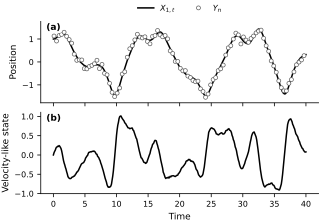

In [10]:
# Define the length of the simulation
t0 = 0.0
t1 = 40.0

# Generate synthetic data
key, path_key, observation_key = jr.split(key, 3)
sol = true_sde.sample_path(path_key, t0, t1, true_x0, dt=dt, dt0=0.05)
xs = sol.ys
ts = sol.ts
us = u(ts)
observation_keys = jr.split(observation_key, xs.shape[0] - 1)
ys = observation_likelihood.sample(xs[1:], us[:-1], observation_keys)
ts_obs = ts[1:]

fig, ax = new_figure(
    size="full_standard", nrows=2, ncols=1, sharex=True
)

ax[0].plot(ts, xs[:, 0], color="black", label=r"$X_{1,t}$")
ax[0].plot(
    ts_obs,
    ys,
    linestyle="none",
    marker="o",
    markevery=4,
    markerfacecolor="white",
    markeredgecolor="0.35",
    markeredgewidth=0.7,
    label=r"$Y_n$",
)
ax[0].set_ylabel("Position")
ax[0].legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2
)

ax[1].plot(ts, xs[:, 1], color="black")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Velocity-like state")
label_panels(ax)
finalize_axes(ax)

plt.show()

## Bootstrap filtering

The filter assimilates the first 200 measurements, covering $t_1=0.1$ through $t_{200}=20$. The array of training controls contains the corresponding left-endpoint values $u_0,\ldots,u_{199}$. At every step, the bootstrap filter resamples the current approximation, propagates each particle through the transition model, and weights the propagated particles by the new position likelihood. The returned trajectory contains the prior approximation at $t_0$ followed by 200 filtering distributions.

Estimated log marginal likelihood: 148.5
Filtering-median RMSE: position=0.088, velocity-like state=0.106
Minimum normalized ESS: 0.072


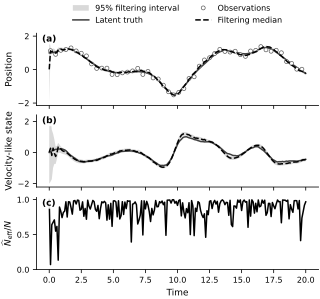

In [11]:
class IndependentKeyBootstrapFilter(dax.BootstrapFilter):
    """Bootstrap filter with separate resampling and propagation keys."""

    @eqx.filter_jit
    def filter(self, ssm, controls, observations, key):
        def step(carry, control_observation):
            pa, step_key, log_likelihood = carry
            control, observation = control_observation
            step_key, resampling_key, propagation_key = jr.split(step_key, 3)
            resampled_pa = pa.resample(resampling_key)
            particle_keys = jr.split(propagation_key, self.num_particles)
            particles_next = ssm.transition.sample(
                resampled_pa.particles, control, particle_keys
            )
            log_weights_next = ssm.likelihood.log_prob(
                observation, particles_next, control
            )
            log_increment = (
                jax.scipy.special.logsumexp(log_weights_next)
                - jnp.log(self.num_particles)
            )
            pa_next = dax.ParticleApproximation(
                particles_next, log_weights_next
            ).normalize()
            return (
                pa_next,
                step_key,
                log_likelihood + log_increment,
            ), pa_next

        key, initial_key = jr.split(key)
        initial_keys = jr.split(initial_key, self.num_particles)
        pa0 = dax.ParticleApproximation(ssm.x0.sample(initial_keys))
        initial = (pa0, key, jnp.array(0.0))
        (_, _, log_likelihood), pas_rest = jax.lax.scan(
            step, initial, (controls, observations)
        )
        pas = dax.TrajectoryParticleApproximation.make_from_init_and_rest(
            pa0, pas_rest
        )
        return pas, log_likelihood


num_train_transitions = 200
us_train = us[:num_train_transitions]
ys_train = ys[:num_train_transitions]
ts_train_state = ts[:num_train_transitions + 1]
ts_train_obs = ts_obs[:num_train_transitions]

num_particles = 10_000
particle_filter = IndependentKeyBootstrapFilter(num_particles=num_particles)
key, subkey = jr.split(key)
pas, log_marginal_likelihood = particle_filter.filter(
    ssm, us_train, ys_train, subkey
)

key, subkey = jr.split(key)
lower, median, upper = pas.get_credible_interval(subkey)
effective_sample_size = 1.0 / jnp.sum(pas.weights**2, axis=1)
ess_fraction = effective_sample_size / num_particles
position_rmse = jnp.sqrt(
    jnp.mean((median[:, 0] - xs[:num_train_transitions + 1, 0]) ** 2)
)
velocity_rmse = jnp.sqrt(
    jnp.mean((median[:, 1] - xs[:num_train_transitions + 1, 1]) ** 2)
)

print(f"Estimated log marginal likelihood: {float(log_marginal_likelihood):.1f}")
print(f"Filtering-median RMSE: position={float(position_rmse):.3f}, "
      f"velocity-like state={float(velocity_rmse):.3f}")
print(f"Minimum normalized ESS: {float(jnp.min(ess_fraction[1:])):.3f}")

fig, ax = new_figure(
    size="full_tall", nrows=3, ncols=1, sharex=True
)

ax[0].fill_between(
    ts_train_state, lower[:, 0], upper[:, 0],
    facecolor="0.85", edgecolor="none", label="95% filtering interval"
)
ax[0].plot(
    ts_train_state, xs[:num_train_transitions + 1, 0],
    color="0.25", linestyle="-", label="Latent truth"
)
ax[0].plot(
    ts_train_obs, ys_train, linestyle="none", marker="o", markevery=4,
    markerfacecolor="white", markeredgecolor="0.35", markeredgewidth=0.7,
    label="Observations"
)
ax[0].plot(
    ts_train_state, median[:, 0], color="black", linestyle="--",
    label="Filtering median"
)
ax[0].set_ylabel("Position")
ax[0].legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2
)

ax[1].fill_between(
    ts_train_state, lower[:, 1], upper[:, 1],
    facecolor="0.85", edgecolor="none"
)
ax[1].plot(
    ts_train_state, xs[:num_train_transitions + 1, 1],
    color="0.25", linestyle="-"
)
ax[1].plot(
    ts_train_state, median[:, 1], color="black", linestyle="--"
)
ax[1].set_ylabel("Velocity-like state")

ax[2].plot(ts_train_state, ess_fraction, color="black")
ax[2].set_ylim(0.0, 1.03)
ax[2].set_xlabel("Time")
ax[2].set_ylabel(r"$\widehat{N}_{\mathrm{eff}}/N$")

label_panels(ax)
finalize_axes(ax)
plt.show()

The position observations rapidly move the particles from the diffuse initial prior toward the realized trajectory. The same updates also reconstruct the unobserved velocity-like state because the transition model couples the two state components. The effective sample size is lowest during the initial correction and then remains high for most updates. A low post-update ESS means that the observation concentrated the weights on relatively few particles; this implementation resamples those weights before the next propagation step.

## Forecasting without new observations

At $t=20$, the observation updates stop. The forecast starts from the filtering distribution at that time and repeatedly applies the stochastic transition model. It therefore approximates $p(\boldsymbol{X}_t\mid y_{1:200},u_{0:t-1})$ for $t>20$ with the model parameters held fixed. No held-out observation is used to recenter the forecast.

Pointwise held-out coverage: position=1.000, velocity-like state=1.000


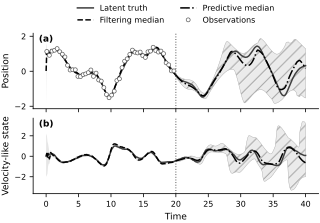

In [12]:
ts_forecast = ts[num_train_transitions:]
us_forecast = us[num_train_transitions:-1]

key, resampling_key, propagation_key, interval_key = jr.split(key, 4)
start_particles = pas[-1].resample(resampling_key).particles
step_keys = jr.split(propagation_key, us_forecast.shape[0])


def forecast_step(particles, control_and_key):
    control, step_key = control_and_key
    particle_keys = jr.split(step_key, particles.shape[0])
    particles_next = ssm.transition.sample(particles, control, particle_keys)
    return particles_next, particles_next


_, future_particles = jax.lax.scan(
    forecast_step, start_particles, (us_forecast, step_keys)
)
forecast_particles = jnp.concatenate(
    [start_particles[None, :, :], future_particles], axis=0
)
forecast_pa = dax.TrajectoryParticleApproximation(
    forecast_particles, resampled=True
)
lower_forecast, median_forecast, upper_forecast = (
    forecast_pa.get_credible_interval(interval_key)
)

held_out_truth = xs[num_train_transitions + 1:]
forecast_coverage = jnp.mean(
    (held_out_truth >= lower_forecast[1:])
    & (held_out_truth <= upper_forecast[1:]),
    axis=0,
)
print(
    "Pointwise held-out coverage: "
    f"position={float(forecast_coverage[0]):.3f}, "
    f"velocity-like state={float(forecast_coverage[1]):.3f}"
)

fig, ax = new_figure(
    size="full_standard", nrows=2, ncols=1, sharex=True
)

for state_index in range(2):
    ax[state_index].fill_between(
        ts_train_state,
        lower[:, state_index],
        upper[:, state_index],
        facecolor="0.90",
        edgecolor="none",
    )
    ax[state_index].fill_between(
        ts_forecast,
        lower_forecast[:, state_index],
        upper_forecast[:, state_index],
        facecolor="0.92",
        edgecolor="0.65",
        linewidth=0.4,
        hatch="//",
    )
    ax[state_index].plot(
        ts, xs[:, state_index], color="0.25", linestyle="-",
        label="Latent truth" if state_index == 0 else None,
    )
    ax[state_index].plot(
        ts_train_state, median[:, state_index], color="black",
        linestyle="--", label="Filtering median" if state_index == 0 else None,
    )
    ax[state_index].plot(
        ts_forecast, median_forecast[:, state_index], color="black",
        linestyle="-.", label="Predictive median" if state_index == 0 else None,
    )
    ax[state_index].axvline(
        ts[num_train_transitions], color="0.35", linestyle=":", linewidth=1.0
    )

ax[0].plot(
    ts_train_obs, ys_train, linestyle="none", marker="o", markevery=4,
    markerfacecolor="white", markeredgecolor="0.35", markeredgewidth=0.7,
    label="Observations",
)
ax[0].set_ylabel("Position")
ax[0].legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2
)
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Velocity-like state")
label_panels(ax)
finalize_axes(ax)
plt.show()

After the observations stop, the predictive median gradually loses phase information while the predictive intervals widen. In this realization, both state components remain inside their pointwise 95% predictive intervals throughout the held-out window. Coverage of one realized path is a diagnostic, not a calibration guarantee. Increasing the number of particles reduces Monte Carlo error in the approximation; it does not remove the intrinsic forecast uncertainty created by process noise and nonlinear dynamics.

A filtering distribution at an early time uses only observations available up to that time. The next notebook uses smoothing to let later observations revise earlier state estimates.

## Exercises

1. Starting from the Itô SDE, derive the Euler--Maruyama covariance $\Delta t\,\operatorname{diag}(\sigma_x^2,\sigma_v^2)$. Explain why each discrete-time noise standard deviation contains $\sqrt{\Delta t}$.
2. Increase the observation standard deviation $s$. Compare the filtering error, the credible-interval width, and the effective sample size with the baseline run.
3. Repeat the calculation with several particle counts while keeping the model, random-number seeds, and forecast horizon fixed. Separate Monte Carlo variability from the intrinsic width of the predictive distribution.
4. Choose a different physical cutoff time for the final observation. Derive the array slices from that time instead of hard-coding a transition count, and compare the resulting forecast horizon and uncertainty.